#  Импорт


In [ ]:
import numpy as np # библиотека Numpy для операций линейной алгебры и прочего
import pandas as pd # Библиотека Pandas для работы с табличными данными
import matplotlib.pyplot as plt # библиотека Matplotlib для визуализации
import matplotlib
from matplotlib.colors import ListedColormap # функция библиотеки Matplotlib, которая генерирует цветовую карту

from sklearn.datasets import make_moons, make_circles, make_classification # генерируемые наборы данных


In [ ]:
plt.style.use('dark_background')

# Данные

Наши старые друзья / знакомые


In [ ]:
def plot_data(ax,ds,name='',marker = 'o',colors =("#FF0000", '#0000FF'),alpha=0.7, s = 150, facecolor=True):
    """Визуализация двумерных  данных для классификации
    Входные переменные:
    ===========
    ax: отдельная ячейка объекта figure
    ds: набор данных, содержащий признаки X и целевые метки y
    name: название графика
    marker: тип маркера - по умолчанию просто круги
    colors: цвета, которые будут использоваться для раскраски разных классов - по умолчанию Красный и Синий
    alpha: прозрачность маркеров
    s: размер маркера (~ квадрат радиуса)
    facecolor:
    """

    X, y = ds # распаковываем признаки и целевые метки в отдельные переменные

    cm_bright = ListedColormap(colors) # формируем цветовую карту из наших цветов
    ax.set_title(name, fontsize = 30) # прописываем название графика
    if facecolor: # если переменная задана, то просто рисуем скатерограмму по признакам с использованием параметров маркеров
        ax.scatter(X[:, 0], X[:, 1],
                   marker = marker, c=y,
                   cmap=cm_bright,s = s,
                   alpha =alpha)
    else: # иначе так же рисуем скатерограмму, но без
        ax.scatter(X[:, 0], X[:, 1],
                   marker = marker, c=y,
                   cmap=cm_bright,s = s,
                   facecolor = 'None',
                   alpha =alpha)
    # немного красоты и аккуратности
    x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5 # фиксируем минимальные и максимальные значения по горизонтали
    y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5 # фиксируем минимальные и максимальные значения по вертикали
    ax.grid(True)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())

In [ ]:
def make_binary_clf(N, method = 'line',
                    noises = 0.15,
                    random_state = 42,):
    """Создание синтетического набора данных
    для бинарной классификации
    Входные переменные:
    ===========
    N: количество точек
    method: тип набора данных
    noises: коэффициент ~ сила шума
    random_state: фиксированный сид случайных чисел (для повторяемости)
    """
    # фиксируем случайный seed
    if random_state: rng = np.random.RandomState(seed = random_state)

    if method == 'line' or method is None:
        # если выбран метод line (или никакой не задан)
        # то мы создаем набор данных с использованием функции make_classification
        # это будут линейно-разделимые данные
        X, y = make_classification(n_samples=N, # количество точек
                                   n_features=2, # количество признаков
                                   n_redundant=0, # количество бесполезных признаков
                                   n_informative=2,# количество информативных признаков
                                   n_clusters_per_class=1, # количество групп точек на класс
                                   class_sep=2, # количество классов
                                   random_state=random_state # фиксированный сид случайных чисел
                                   )
        X += np.random.randn(*X.shape) *noises # добавляем к признакам случайный шум

    elif method == 'moons':
        # если выбран метод moons
        # то мы создаем набор данных с использованием функции make_moons
        # это будут данные похожие на Инь-Ян
        X, y = make_moons(n_samples=N, # количество точек
                          noise=noises, # уровень шума
                          random_state=random_state # фиксированный сид случайных чисел
                          )

    elif method == 'circles':
        # если выбран метод circles
        # то мы создаем набор данных с использованием функции make_circles
        # это будут данные в виде концентрических окружностей
        X, y = make_circles(n_samples=N, # количество точек
                            noise=noises, # уровень шума
                            factor=0.5, # соотношение радиусов внуренней и внешней окружности
                            random_state=random_state # фиксированный сид случайных чисел
                            )


    return X,y

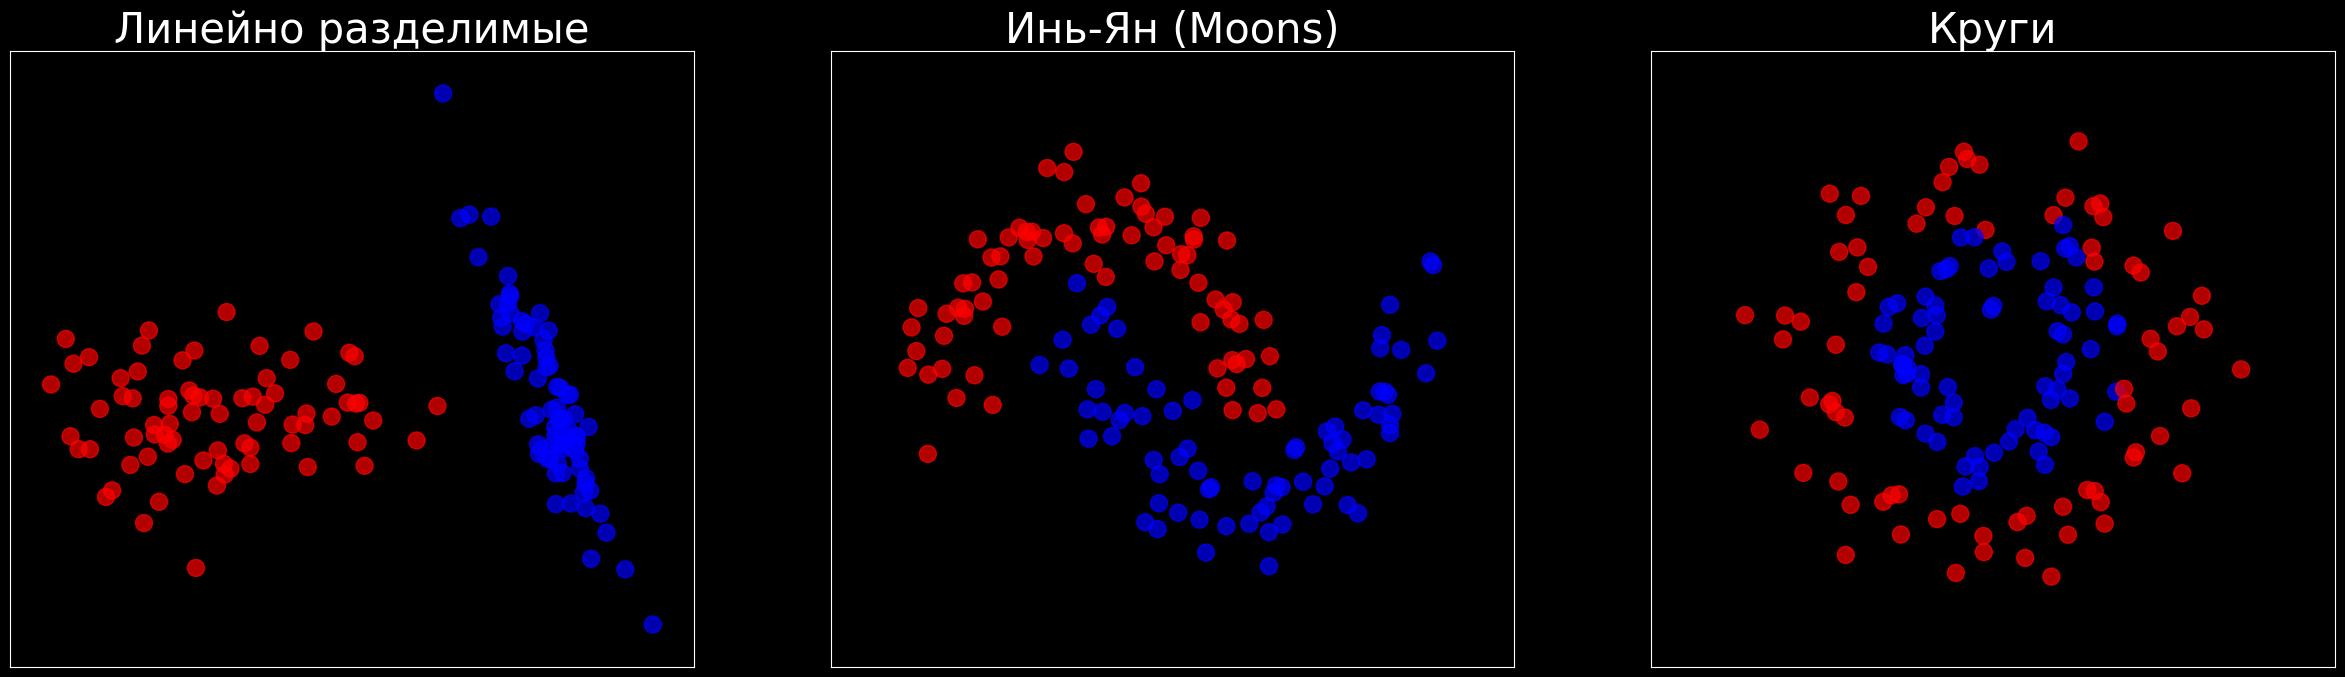

In [ ]:
#@title данные { run: "auto" }
N = 150 #@param {type:"slider", min:50, max:250, step:25}
noises = 0.15 #@param {type:"slider", min:0, max:1, step:0.05}

fig=plt.figure(figsize=(30,8))

ax = plt.subplot(1, 3, 1)
plot_data(ax,make_binary_clf(N,method = 'line',
                             noises = noises),
          'Линейно разделимые')
ax = plt.subplot(1, 3, 2)
plot_data(ax,make_binary_clf(N,method = 'moons',
                             noises = noises),
          'Инь-Ян (Moons)')
ax = plt.subplot(1, 3, 3)
plot_data(ax, make_binary_clf(N,method = 'circles',
                              noises = noises),
          'Круги')




За неимением лучшего аналога тестировать алгоритмы кластеризации будем на тех же наборах, что и классификацию

# DBSCAN

Начнем по традиции с простых данных - линейно разделимых

In [ ]:
N = 150
X,y = make_binary_clf(N,method = 'line', noises=0.05, )

X.shape

(150, 2)

In [ ]:
from sklearn.cluster import DBSCAN # Кластеризация DBSCAN от scikit-learn

По традиции мы сначала создаем объект нужного нам класса, в котором мы можем изменять гиперпараметры

В случае кластеризации **DBSCAN** меняем
    
* `eps` - радиус "поиска" (число исходя из разброса данных)
* `min_samples` - минимальное число точек для скопления




In [ ]:
# Создаем Класс Кластеризации DBSCAN
db = DBSCAN(eps=0.7,
            min_samples=4)

db

DBSCAN(eps=0.7, min_samples=4)

Традиционно обучаем методом `.fit()`

In [ ]:
db.fit(X);

Делаем предсказания - доступен `.fit_predict()` (т.е. **НЕЛЬЗЯ** подставлять новые данные)

Либо можем подсмотреть в атрибуте `.labels_`

In [ ]:
db.labels_

array([ 0,  0,  1,  1,  1,  0,  0,  1,  0,  0,  0,  0, -1,  0,  1,  0,  1,
        0,  1,  0,  0,  0,  0,  0,  0, -1,  1,  1,  0,  1,  1, -1,  1,  0,
        1,  1,  0,  1,  1,  1,  0,  1,  0,  1,  1,  1,  1,  0,  1,  1,  1,
        0,  1,  0,  0,  0,  1,  0,  0,  0,  0,  1,  1,  0,  1,  1,  0,  1,
        0,  0,  1,  1,  0,  1,  0,  1,  0,  1,  1,  0,  1,  0,  1,  1,  0,
        1,  1,  0,  0,  0,  1,  1,  0,  0,  1,  1,  0,  1,  0,  0,  1,  1,
        1,  1,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  1,  0,  1,  1,  0,  0,  1,  0,  0,  0,  1,  0,  1,
        1,  0,  1,  0,  1,  0,  1,  1,  1,  0,  1,  0,  1,  1])

In [ ]:
db.fit_predict(X)

array([ 0,  0,  1,  1,  1,  0,  0,  1,  0,  0,  0,  0, -1,  0,  1,  0,  1,
        0,  1,  0,  0,  0,  0,  0,  0, -1,  1,  1,  0,  1,  1, -1,  1,  0,
        1,  1,  0,  1,  1,  1,  0,  1,  0,  1,  1,  1,  1,  0,  1,  1,  1,
        0,  1,  0,  0,  0,  1,  0,  0,  0,  0,  1,  1,  0,  1,  1,  0,  1,
        0,  0,  1,  1,  0,  1,  0,  1,  0,  1,  1,  0,  1,  0,  1,  1,  0,
        1,  1,  0,  0,  0,  1,  1,  0,  0,  1,  1,  0,  1,  0,  0,  1,  1,
        1,  1,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  1,  0,  1,  1,  0,  0,  1,  0,  0,  0,  1,  0,  1,
        1,  0,  1,  0,  1,  0,  1,  1,  1,  0,  1,  0,  1,  1])

Обращаем ваше внимание DBSCAN помечает `-1` те точки, которые считаются шумовыми

В аттрибуте `.core_sample_indices_` можно подсмотреть индексы для опорных точек (которые не граничные)

In [ ]:
db.core_sample_indices_

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  26,  27,
        28,  29,  30,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,
        43,  44,  45,  46,  47,  48,  49,  51,  52,  53,  54,  55,  56,
        57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
        70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,
        83,  84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,
        96,  97,  98,  99, 101, 102, 103, 104, 105, 106, 107, 108, 110,
       111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123,
       124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136,
       137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149])

Запишем функцию для визуализации результатов кластеризации

In [ ]:
def plot_clustering(X, db):
    """Визуализация результатов кластеризации
    Входные переменные:
    ===========
    X: данные, на которых мы хотим построить визуализацию
    db: обученный класс DBSCAN
    """
    # ищем индексы опорных точек
    core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
    core_samples_mask[db.core_sample_indices_] = True

    # берем метки данных
    labels = db.labels_
    # число кластеров: количество уникальных значений - шум если есть
    n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise_ = list(labels).count(-1)

    unique_labels = set(labels)

    # выбираем цветовую карту - мне нравится 'bwr'
    cmap = matplotlib.colormaps['bwr']
    # для каждого кластера выбираем свой цвет
    colors = [cmap(each)
            for each in
            np.linspace(0, 1, len(unique_labels))]

    plt.figure(figsize=(5,5))

    for k, col in zip(unique_labels, colors):
        if k == -1:
            # Используем для шума зеленый
            col = [0, 1, 0, 0]

        class_member_mask = (labels == k)
        # опорные точки рисуем побольше
        xy = X[class_member_mask & core_samples_mask]
        plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
                markeredgecolor='w', markersize=15, alpha=0.9)
        # граничные точки рисуем поменьше и более прозрачно
        xy = X[class_member_mask & ~core_samples_mask]
        plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
                markeredgecolor='w', markersize=5, alpha=0.6)

    plt.xticks([],[])
    plt.yticks([],[])
    plt.title('Предполагаемое количество кластеров: %d' % n_clusters_);

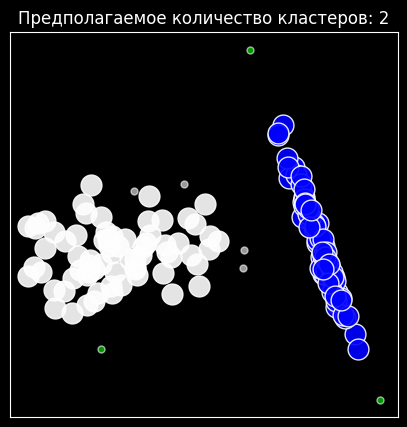

In [ ]:
plot_clustering(X, db)

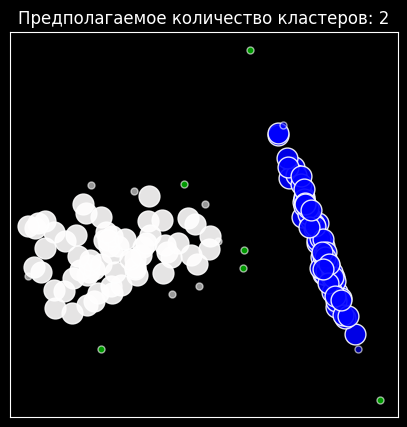

In [ ]:
#@title Применение кластеризации DBSCAN { run: "auto" }
#@markdown ### Настраиваем гиперпараметры
#@markdown ### epsilon
eps = 0.5 #@param {type:"slider", min:0, max:5, step:0.05}
#@markdown ### minimum sample
min_samples = 4 #@param {type:"slider", min:0, max:25, step:1}


# создаем объект
db = DBSCAN(eps=eps,
            min_samples=min_samples)

# обучаем на данных
db.fit(X)

plot_clustering(X, db)

# Задание

Проверить алгоритм Кластеризации DBSCAN на данных Инь-Ян  и Круги

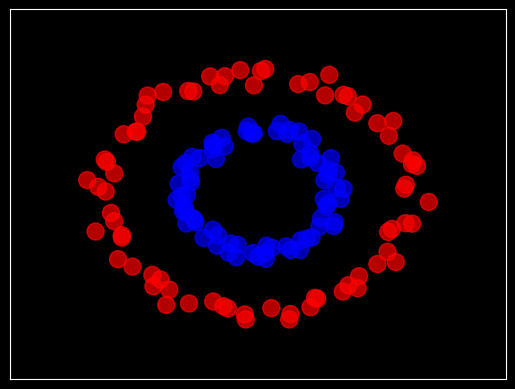

In [ ]:
N = 150
X_circle,y_circle = make_binary_clf(N,method = 'circles', noises=0.05, )
ax = plt.subplot(1, 1, 1)
plot_data(ax,(X_circle,y_circle))

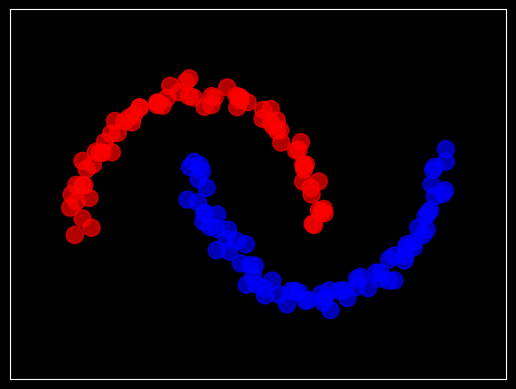

In [ ]:
N = 150
X_moons,y_moons = make_binary_clf(N,method = 'moons', noises=0.05, )
ax = plt.subplot(1, 1, 1)
plot_data(ax,(X_moons,y_moons))